In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
DATA_DIR = '../data'
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
order_items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')
reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')
products = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
categories = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

print('Dataset Shapes:')
for name, df in [('customers', customers), ('orders', orders), ('order_items', order_items),
                  ('payments', payments), ('reviews', reviews), ('products', products),
                  ('sellers', sellers), ('categories', categories)]:
    print(f'  {name}: {df.shape}')

Dataset Shapes:
  customers: (99441, 5)
  orders: (99441, 8)
  order_items: (112650, 7)
  payments: (103886, 5)
  reviews: (99224, 7)
  products: (32951, 9)
  sellers: (3095, 4)
  categories: (71, 2)


In [3]:
print('=== Missing Values ===')
for name, df in [('orders', orders), ('order_items', order_items), ('products', products)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n{name}:')
        print(nulls)

=== Missing Values ===

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [4]:
products = products.merge(categories, on='product_category_name', how='left')
products['category'] = products['product_category_name_english'].fillna('unknown')

df = order_items.merge(orders, on='order_id') \
    .merge(customers, on='customer_id') \
    .merge(products[['product_id', 'category', 'product_weight_g']], on='product_id') \
    .merge(sellers, on='seller_id')

df = df[df['order_status'] == 'delivered'].copy()
df['total_value'] = df['price'] + df['freight_value']
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delta'] = df['estimated_days'] - df['delivery_days']
df['is_late'] = (df['delivery_delta'] < 0).astype(int)
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f'Enriched dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Enriched dataset: 110197 rows, 29 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_weight_g,seller_zip_code_prefix,seller_city,seller_state,total_value,delivery_days,estimated_days,delivery_delta,is_late,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,650.0,27277,volta redonda,SP,72.19,7.0,15,8.0,0,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,30000.0,3471,sao paulo,SP,259.83,16.0,18,2.0,0,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,3050.0,37564,borda da mata,MG,216.87,7.0,21,14.0,0,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,200.0,14403,franca,SP,25.78,6.0,11,5.0,0,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,3750.0,87900,loanda,PR,218.04,25.0,40,15.0,0,2017-02


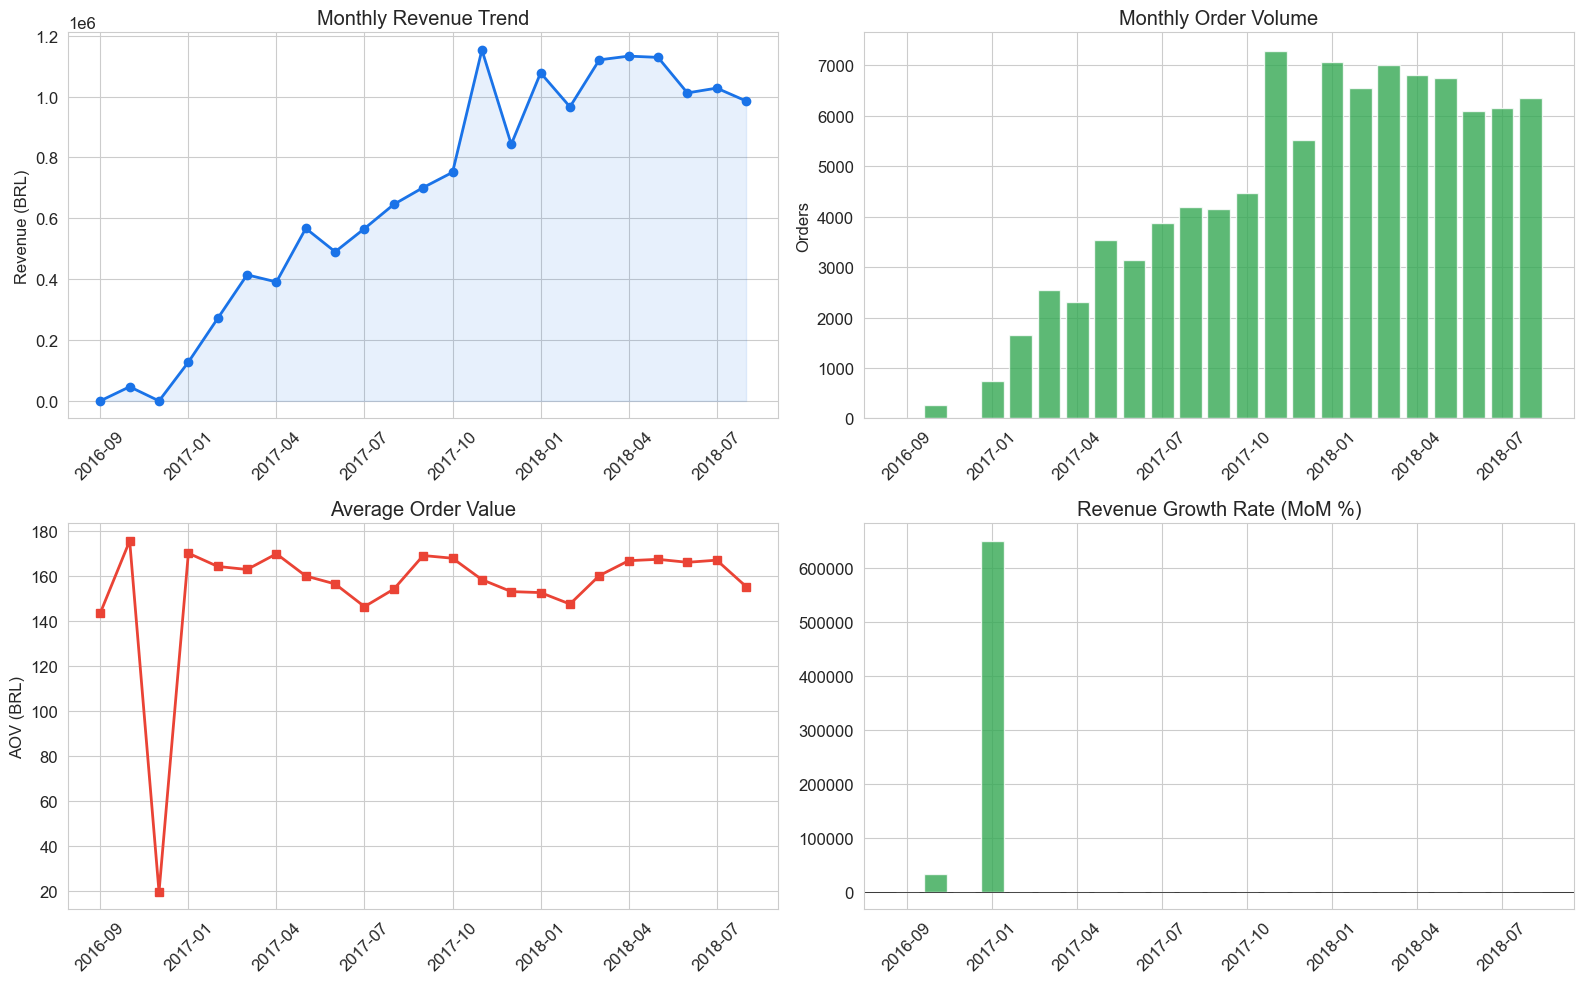

In [5]:
monthly = df.groupby('order_month').agg(
    revenue=('total_value', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)
monthly['aov'] = monthly['revenue'] / monthly['orders']
monthly['revenue_growth'] = monthly['revenue'].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(range(len(monthly)), monthly['revenue'], marker='o', color='#1a73e8', linewidth=2)
axes[0,0].fill_between(range(len(monthly)), monthly['revenue'], alpha=0.1, color='#1a73e8')
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xticks(range(0, len(monthly), 3))
axes[0,0].set_xticklabels(monthly['order_month'].iloc[::3], rotation=45)
axes[0,0].set_ylabel('Revenue (BRL)')

axes[0,1].bar(range(len(monthly)), monthly['orders'], color='#34a853', alpha=0.8)
axes[0,1].set_title('Monthly Order Volume')
axes[0,1].set_xticks(range(0, len(monthly), 3))
axes[0,1].set_xticklabels(monthly['order_month'].iloc[::3], rotation=45)
axes[0,1].set_ylabel('Orders')

axes[1,0].plot(range(len(monthly)), monthly['aov'], marker='s', color='#ea4335', linewidth=2)
axes[1,0].set_title('Average Order Value')
axes[1,0].set_xticks(range(0, len(monthly), 3))
axes[1,0].set_xticklabels(monthly['order_month'].iloc[::3], rotation=45)
axes[1,0].set_ylabel('AOV (BRL)')

colors = ['#ea4335' if g < 0 else '#34a853' for g in monthly['revenue_growth'].fillna(0)]
axes[1,1].bar(range(len(monthly)), monthly['revenue_growth'].fillna(0), color=colors, alpha=0.8)
axes[1,1].set_title('Revenue Growth Rate (MoM %)')
axes[1,1].set_xticks(range(0, len(monthly), 3))
axes[1,1].set_xticklabels(monthly['order_month'].iloc[::3], rotation=45)
axes[1,1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../reports/monthly_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

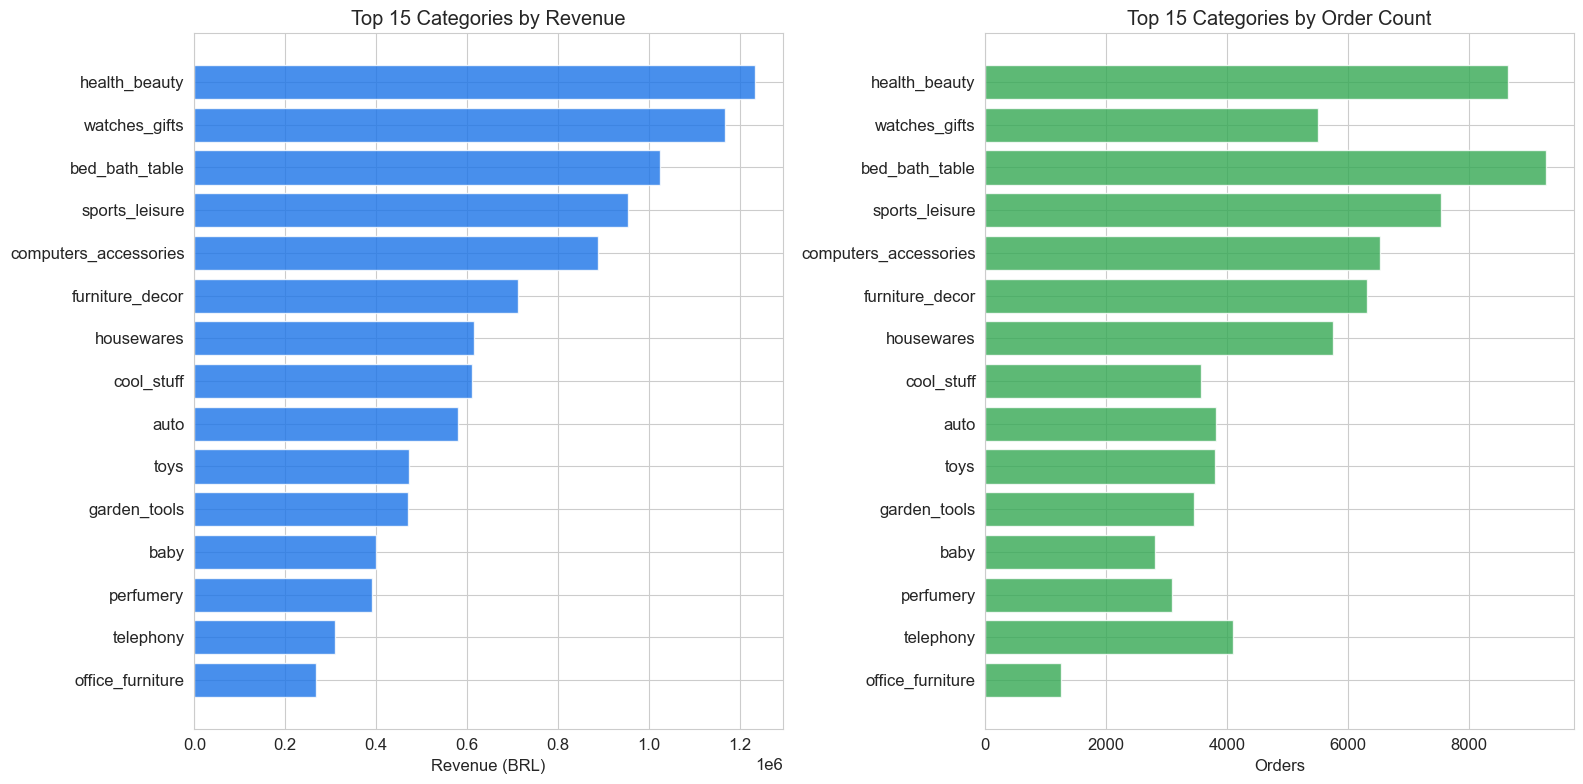

In [6]:
top_categories = df.groupby('category').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).sort_values('revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(len(top_categories)), top_categories['revenue'], color='#1a73e8', alpha=0.8)
axes[0].set_yticks(range(len(top_categories)))
axes[0].set_yticklabels(top_categories.index)
axes[0].set_title('Top 15 Categories by Revenue')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].invert_yaxis()

axes[1].barh(range(len(top_categories)), top_categories['orders'], color='#34a853', alpha=0.8)
axes[1].set_yticks(range(len(top_categories)))
axes[1].set_yticklabels(top_categories.index)
axes[1].set_title('Top 15 Categories by Order Count')
axes[1].set_xlabel('Orders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

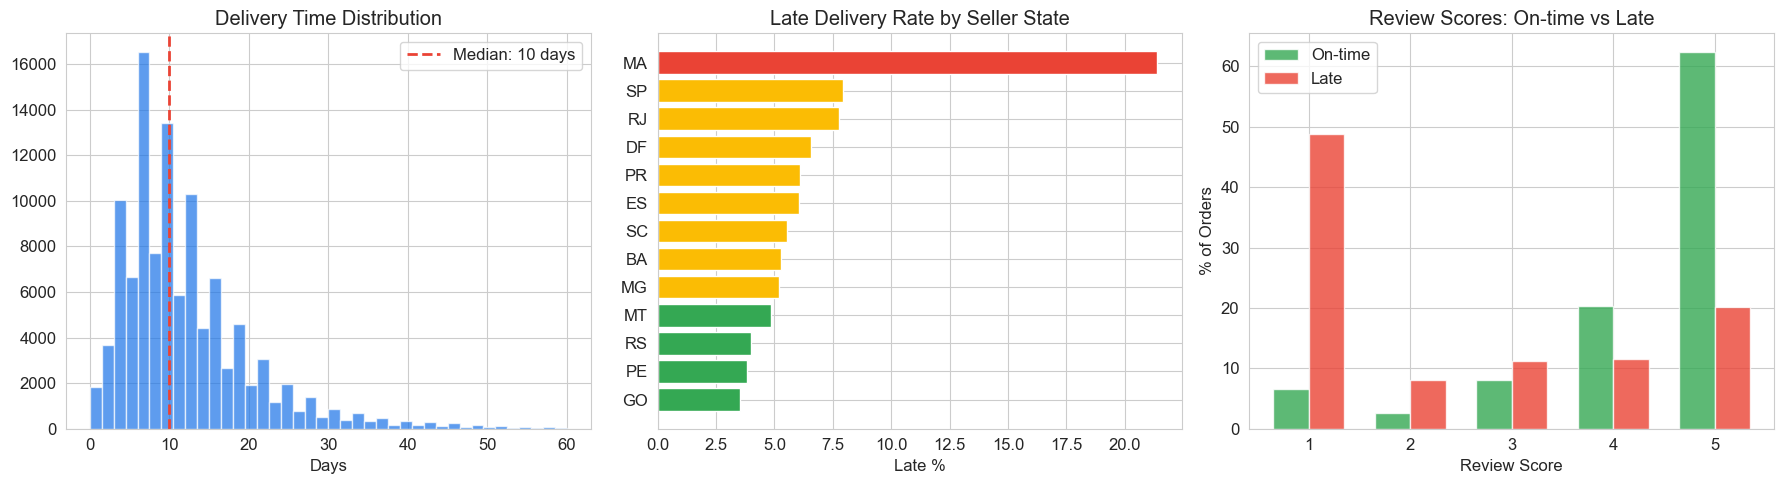

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

delivery_valid = df[df['delivery_days'].between(0, 60)]
axes[0].hist(delivery_valid['delivery_days'], bins=40, color='#1a73e8', alpha=0.7, edgecolor='white')
axes[0].axvline(delivery_valid['delivery_days'].median(), color='#ea4335', linestyle='--', linewidth=2, label=f"Median: {delivery_valid['delivery_days'].median():.0f} days")
axes[0].set_title('Delivery Time Distribution')
axes[0].set_xlabel('Days')
axes[0].legend()

late_by_state = df.groupby('seller_state')['is_late'].agg(['mean', 'count'])
late_by_state = late_by_state[late_by_state['count'] >= 100].sort_values('mean', ascending=False).head(15)
colors = ['#ea4335' if v > 0.10 else '#fbbc04' if v > 0.05 else '#34a853' for v in late_by_state['mean']]
axes[1].barh(range(len(late_by_state)), late_by_state['mean'] * 100, color=colors)
axes[1].set_yticks(range(len(late_by_state)))
axes[1].set_yticklabels(late_by_state.index)
axes[1].set_title('Late Delivery Rate by Seller State')
axes[1].set_xlabel('Late %')
axes[1].invert_yaxis()

review_dist = df.groupby('order_id')['order_id'].first().reset_index(drop=True)
review_data = df.drop_duplicates('order_id').merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
late_reviews = review_data[review_data['is_late'] == 1]['review_score'].value_counts().sort_index()
ontime_reviews = review_data[review_data['is_late'] == 0]['review_score'].value_counts().sort_index()
x = np.arange(1, 6)
w = 0.35
axes[2].bar(x - w/2, ontime_reviews.reindex(x, fill_value=0) / ontime_reviews.sum() * 100, w, label='On-time', color='#34a853', alpha=0.8)
axes[2].bar(x + w/2, late_reviews.reindex(x, fill_value=0) / late_reviews.sum() * 100, w, label='Late', color='#ea4335', alpha=0.8)
axes[2].set_title('Review Scores: On-time vs Late')
axes[2].set_xlabel('Review Score')
axes[2].set_ylabel('% of Orders')
axes[2].set_xticks(x)
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

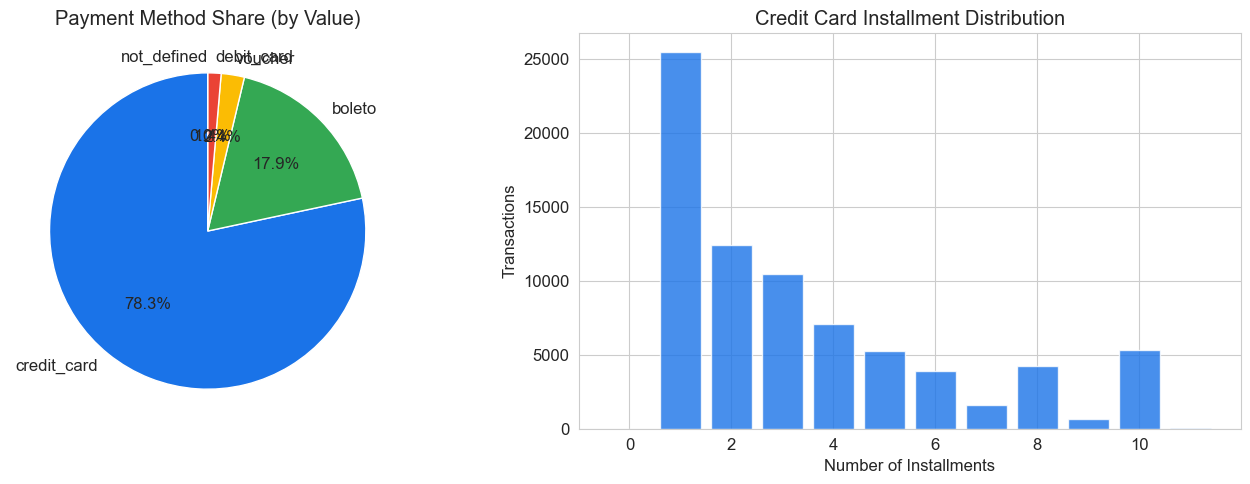

In [8]:
payment_summary = payments.groupby('payment_type').agg(
    transactions=('payment_value', 'count'),
    total_value=('payment_value', 'sum'),
    avg_value=('payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean')
).sort_values('total_value', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['#1a73e8', '#34a853', '#fbbc04', '#ea4335', '#9334e6']
axes[0].pie(payment_summary['total_value'], labels=payment_summary.index, autopct='%1.1f%%',
            colors=colors_pie[:len(payment_summary)], startangle=90)
axes[0].set_title('Payment Method Share (by Value)')

credit_installments = payments[payments['payment_type'] == 'credit_card']
installment_dist = credit_installments['payment_installments'].value_counts().sort_index().head(12)
axes[1].bar(installment_dist.index, installment_dist.values, color='#1a73e8', alpha=0.8)
axes[1].set_title('Credit Card Installment Distribution')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Transactions')

plt.tight_layout()
plt.savefig('../reports/payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

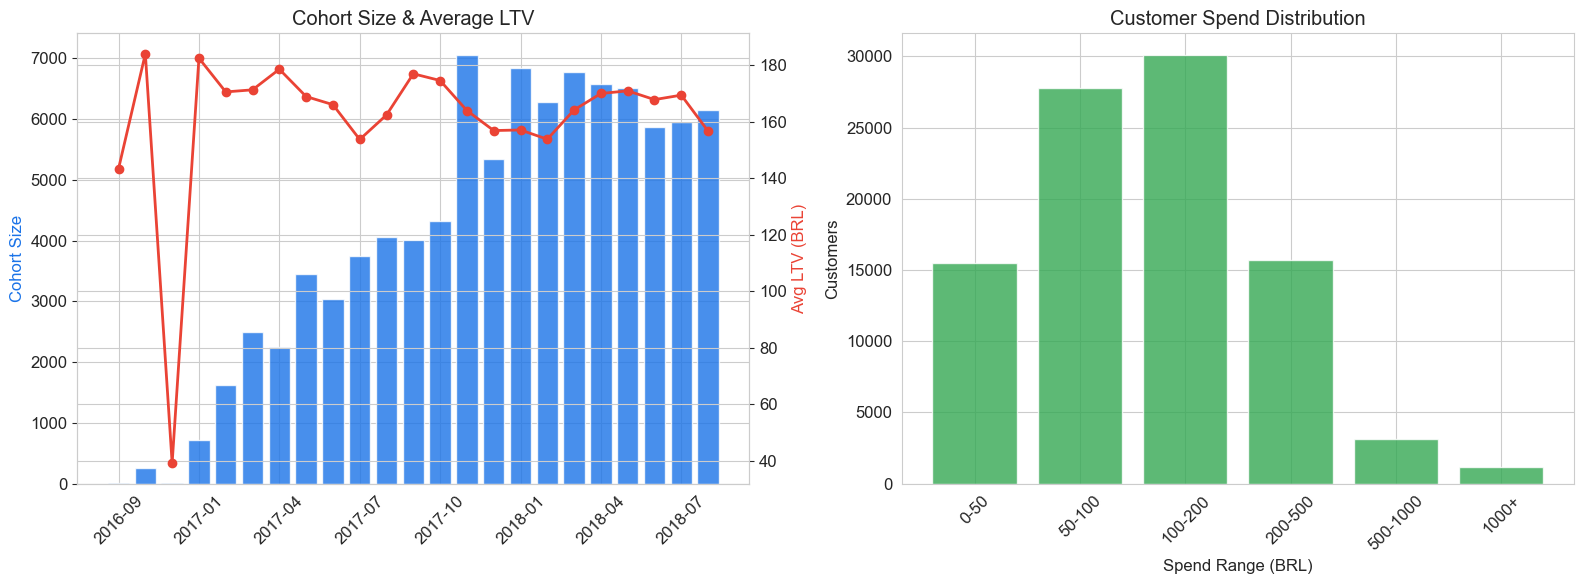

Total unique customers: 93,358
Repeat purchase rate: 3.00%
Average LTV: BRL 165.17
Median LTV: BRL 107.78


In [9]:
customer_ltv = df.groupby('customer_unique_id').agg(
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max'),
    order_count=('order_id', 'nunique'),
    total_spend=('total_value', 'sum'),
    avg_order_value=('total_value', 'mean')
).reset_index()

customer_ltv['cohort'] = customer_ltv['first_order'].dt.to_period('M').astype(str)

cohort_summary = customer_ltv.groupby('cohort').agg(
    cohort_size=('customer_unique_id', 'count'),
    avg_ltv=('total_spend', 'mean'),
    repeat_customers=('order_count', lambda x: (x > 1).sum())
).reset_index()
cohort_summary['repeat_rate'] = cohort_summary['repeat_customers'] / cohort_summary['cohort_size'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(cohort_summary)), cohort_summary['cohort_size'], color='#1a73e8', alpha=0.8)
ax2 = axes[0].twinx()
ax2.plot(range(len(cohort_summary)), cohort_summary['avg_ltv'], color='#ea4335', marker='o', linewidth=2)
axes[0].set_title('Cohort Size & Average LTV')
axes[0].set_xticks(range(0, len(cohort_summary), 3))
axes[0].set_xticklabels(cohort_summary['cohort'].iloc[::3], rotation=45)
axes[0].set_ylabel('Cohort Size', color='#1a73e8')
ax2.set_ylabel('Avg LTV (BRL)', color='#ea4335')

spend_bins = [0, 50, 100, 200, 500, 1000, float('inf')]
spend_labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
customer_ltv['spend_segment'] = pd.cut(customer_ltv['total_spend'], bins=spend_bins, labels=spend_labels)
segment_counts = customer_ltv['spend_segment'].value_counts().sort_index()
axes[1].bar(range(len(segment_counts)), segment_counts.values, color='#34a853', alpha=0.8)
axes[1].set_xticks(range(len(segment_counts)))
axes[1].set_xticklabels(segment_counts.index, rotation=45)
axes[1].set_title('Customer Spend Distribution')
axes[1].set_xlabel('Spend Range (BRL)')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('../reports/customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique customers: {len(customer_ltv):,}")
print(f"Repeat purchase rate: {(customer_ltv['order_count'] > 1).mean() * 100:.2f}%")
print(f"Average LTV: BRL {customer_ltv['total_spend'].mean():.2f}")
print(f"Median LTV: BRL {customer_ltv['total_spend'].median():.2f}")

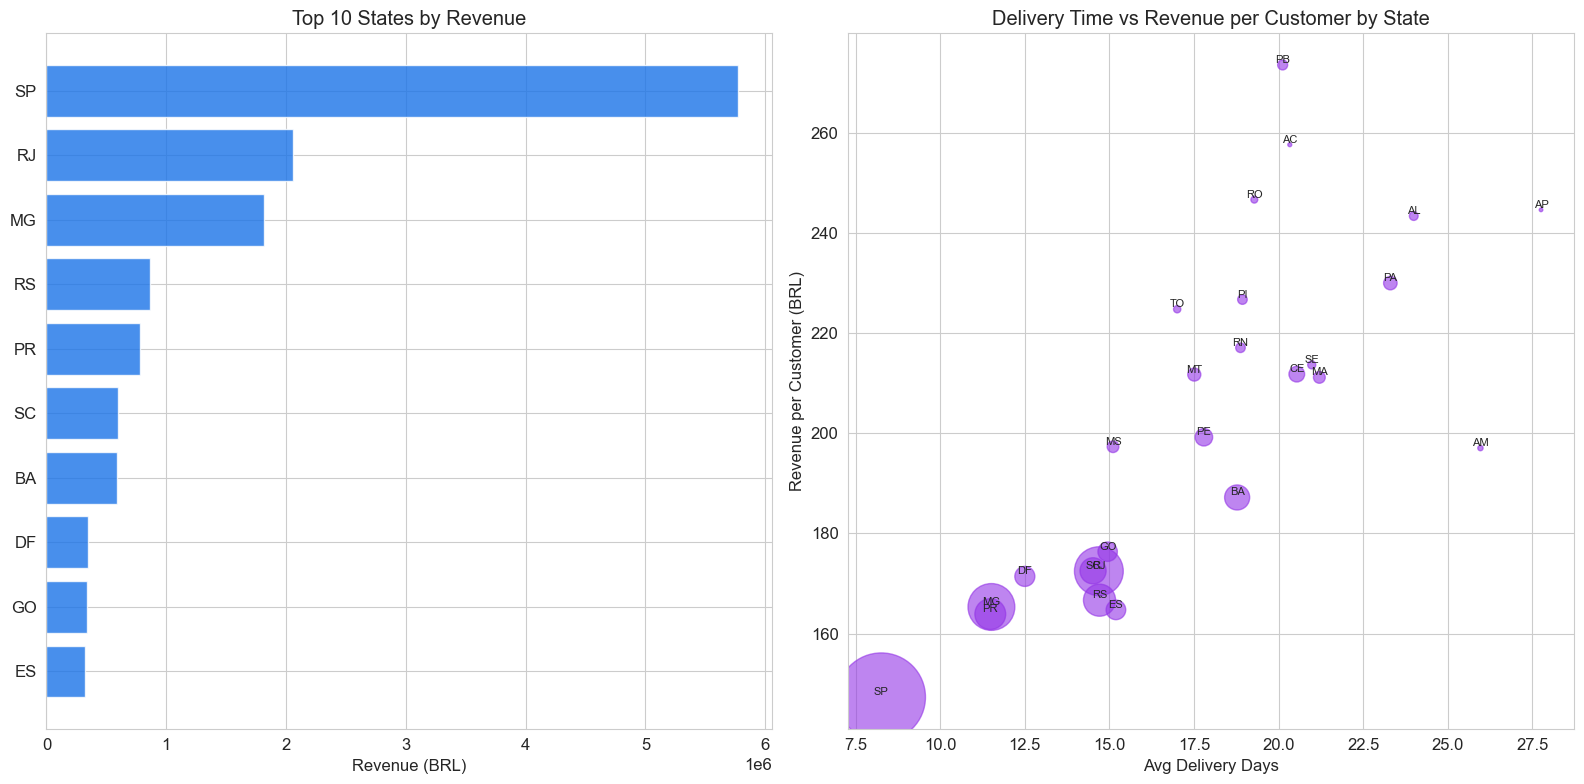

In [10]:
state_metrics = df.groupby('customer_state').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_value', 'sum'),
    customers=('customer_unique_id', 'nunique'),
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
).sort_values('revenue', ascending=False)
state_metrics['rev_per_customer'] = state_metrics['revenue'] / state_metrics['customers']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_states = state_metrics.head(10)
axes[0].barh(range(len(top_states)), top_states['revenue'], color='#1a73e8', alpha=0.8)
axes[0].set_yticks(range(len(top_states)))
axes[0].set_yticklabels(top_states.index)
axes[0].set_title('Top 10 States by Revenue')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].invert_yaxis()

scatter_data = state_metrics[state_metrics['orders'] >= 50]
scatter = axes[1].scatter(scatter_data['avg_delivery'], scatter_data['rev_per_customer'],
                          s=scatter_data['orders'] / 10, alpha=0.6, color='#9334e6')
for state in scatter_data.index:
    axes[1].annotate(state, (scatter_data.loc[state, 'avg_delivery'], scatter_data.loc[state, 'rev_per_customer']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_title('Delivery Time vs Revenue per Customer by State')
axes[1].set_xlabel('Avg Delivery Days')
axes[1].set_ylabel('Revenue per Customer (BRL)')

plt.tight_layout()
plt.savefig('../reports/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

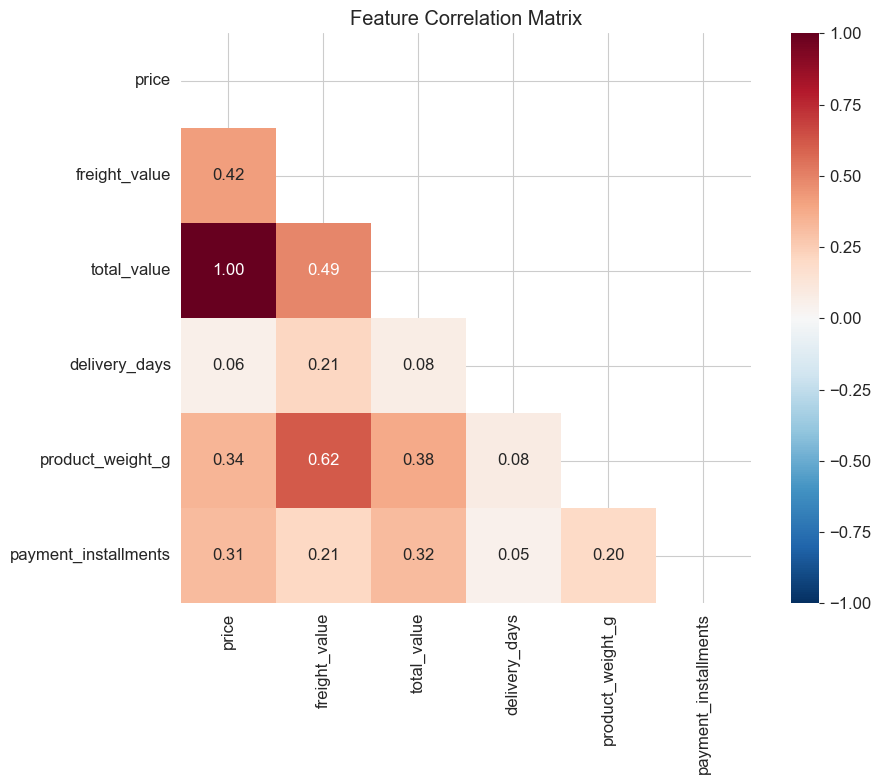

In [12]:
payment_avg = payments.groupby('order_id')['payment_installments'].mean().reset_index()
corr_df = df.drop_duplicates('order_id')[['order_id', 'price', 'freight_value', 'total_value', 'delivery_days', 'product_weight_g']]
corr_df = corr_df.merge(payment_avg, on='order_id', how='left').dropna()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_df.drop(columns='order_id').corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

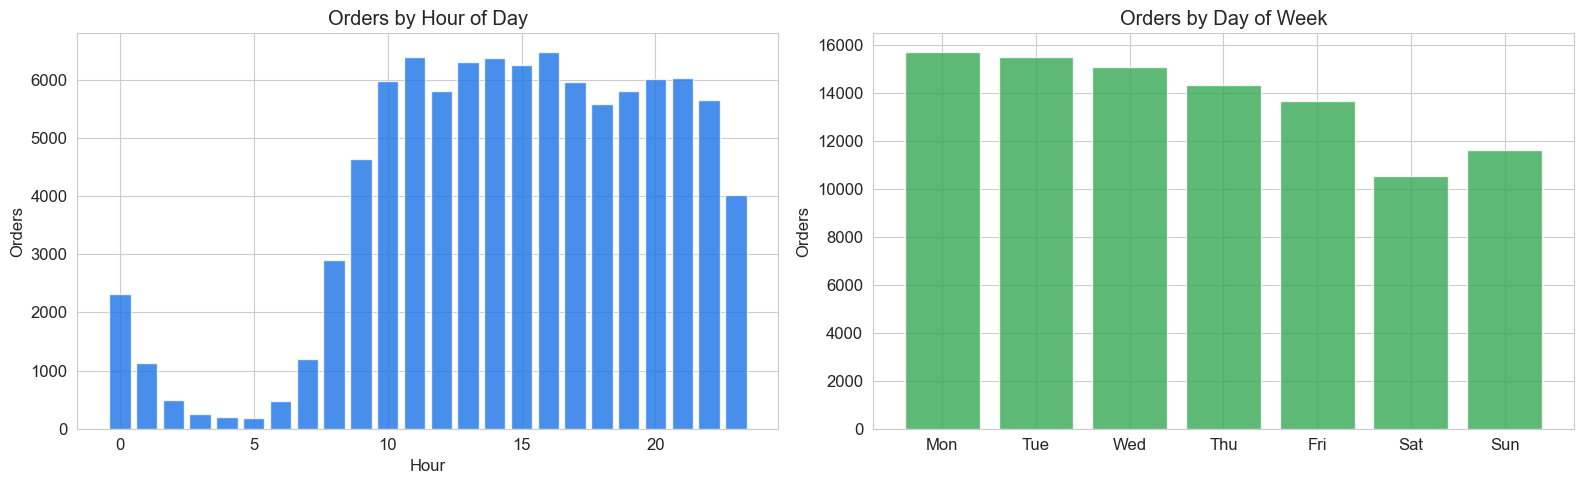

In [13]:
df['hour'] = df['order_purchase_timestamp'].dt.hour
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

hourly = df.groupby('hour')['order_id'].nunique()
daily = df.groupby('day_of_week')['order_id'].nunique()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = daily.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(hourly.index, hourly.values, color='#1a73e8', alpha=0.8)
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Orders')

axes[1].bar(range(7), daily.values, color='#34a853', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_title('Orders by Day of Week')
axes[1].set_ylabel('Orders')

plt.tight_layout()
plt.savefig('../reports/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print('=' * 60)
print('KEY FINDINGS SUMMARY')
print('=' * 60)

total_revenue = df['total_value'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique()
avg_delivery = df['delivery_days'].median()
late_rate = df['is_late'].mean() * 100

print(f'\nTotal Revenue: BRL {total_revenue:,.2f}')
print(f'Total Orders: {total_orders:,}')
print(f'Unique Customers: {total_customers:,}')
print(f'Average Order Value: BRL {total_revenue/total_orders:,.2f}')
print(f'Median Delivery Time: {avg_delivery:.0f} days')
print(f'Late Delivery Rate: {late_rate:.1f}%')
print(f'Repeat Purchase Rate: {(customer_ltv["order_count"] > 1).mean() * 100:.2f}%')

top_state = state_metrics.index[0]
top_cat = top_categories.index[0]
print(f'\nTop State by Revenue: {top_state}')
print(f'Top Category by Revenue: {top_cat}')
print(f'Most Used Payment: Credit Card ({(payments["payment_type"] == "credit_card").mean()*100:.1f}%)')
print(f'Peak Order Hour: {hourly.idxmax()}:00')

KEY FINDINGS SUMMARY

Total Revenue: BRL 15,419,773.75
Total Orders: 96,478
Unique Customers: 93,358
Average Order Value: BRL 159.83
Median Delivery Time: 10 days
Late Delivery Rate: 7.4%
Repeat Purchase Rate: 3.00%

Top State by Revenue: SP
Top Category by Revenue: health_beauty
Most Used Payment: Credit Card (73.9%)
Peak Order Hour: 16:00
